# Example of Agnostic Benchmark application on Regression Task

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import os
import warnings
import sys
sys.path.insert(0, "../../")
import abench

In [2]:
from abench.store.api import get_ABloader,get_component
ABloader = get_ABloader('result',"expert_with:[['V1']]_without[['S1']]_60_1_")

In [3]:
from src. import RF_TS_Classifier # Candidates
dict_RF_uni = {'RF_params':{'n_estimators':100,'random_state':0},
               'mode_multi_RF':False,
               'prediction_number': prediction_number}
Model = RF_TS_Classifier(**dict_RF_uni)

ImportError: cannot import name 'RF_TS_Classifier' from 'src.component' (/scratch/projet_explo/explo_lissi/n5_benchmark/demo/example_regression/src/component.py)

In [26]:
ls

Analyse_benchmark.ipynb*  benchmark.py*     data/              result/
Benchmark_V2/             benchmark.slurm*  model_parameters/  src/


In [3]:
storing = 'result'
#Print result metrics
from abench.benchmark.benchmark import perf_compute_metrics,perf_agg_compute
from abench.store.api import get_ABDataExperiment
from copy import deepcopy

list_component_name = ['LinearRegressor','RidgeRegressor','RandomForestRegressor','GradientBoostingRegressor']
ABcv_experiment_TS = get_ABDataExperiment(storing,'TS_CV_Experiment')

from src.metric import MetricsMae,MetricsMse
list_metrics=[MetricsMae(),MetricsMse()]     

perf_compute_metrics(storing=storing,
                    ABDataExperiment=ABcv_experiment_TS,
                    list_component_name=list_component_name,
                    list_metrics=list_metrics)

experiment_plan = deepcopy(ABcv_experiment_TS).get_experiment_plan()
perf_agg_compute(storing=storing,
                 experiment_plan=experiment_plan,
                 list_component_name=list_component_name,
                 list_metrics=list_metrics)

LinearRegressor mae Train [0.357] ± [0.006] | TEST [0.349] ± [0.009]
LinearRegressor mse Train [0.25] ± [0.008] | TEST [0.237] ± [0.018]
RidgeRegressor mae Train [0.357] ± [0.006] | TEST [0.349] ± [0.009]
RidgeRegressor mse Train [0.25] ± [0.008] | TEST [0.237] ± [0.018]
RandomForestRegressor mae Train [0.104] ± [0.004] | TEST [0.271] ± [0.009]
RandomForestRegressor mse Train [0.025] ± [0.002] | TEST [0.169] ± [0.01]
GradientBoostingRegressor mae Train [0.251] ± [0.003] | TEST [0.273] ± [0.006]
GradientBoostingRegressor mse Train [0.133] ± [0.006] | TEST [0.166] ± [0.008]


# Benchmark 

In [10]:
# Agg_plot 
storing = 'result'
list_component_name = ['LinearRegressor','RidgeRegressor','RandomForestRegressor','GradientBoostingRegressor']
colors=[[0,1,1],[0,0.5,1],[1,1,0],[1,0.5,0]]

from abench.store.api import get_dictperf,get_output,get_ABloader
from abench.visu.visu import scatter_result,plot_curve
Metrics_performance = ['mae','mse']

dict_perf = get_dictperf(storing,'all')

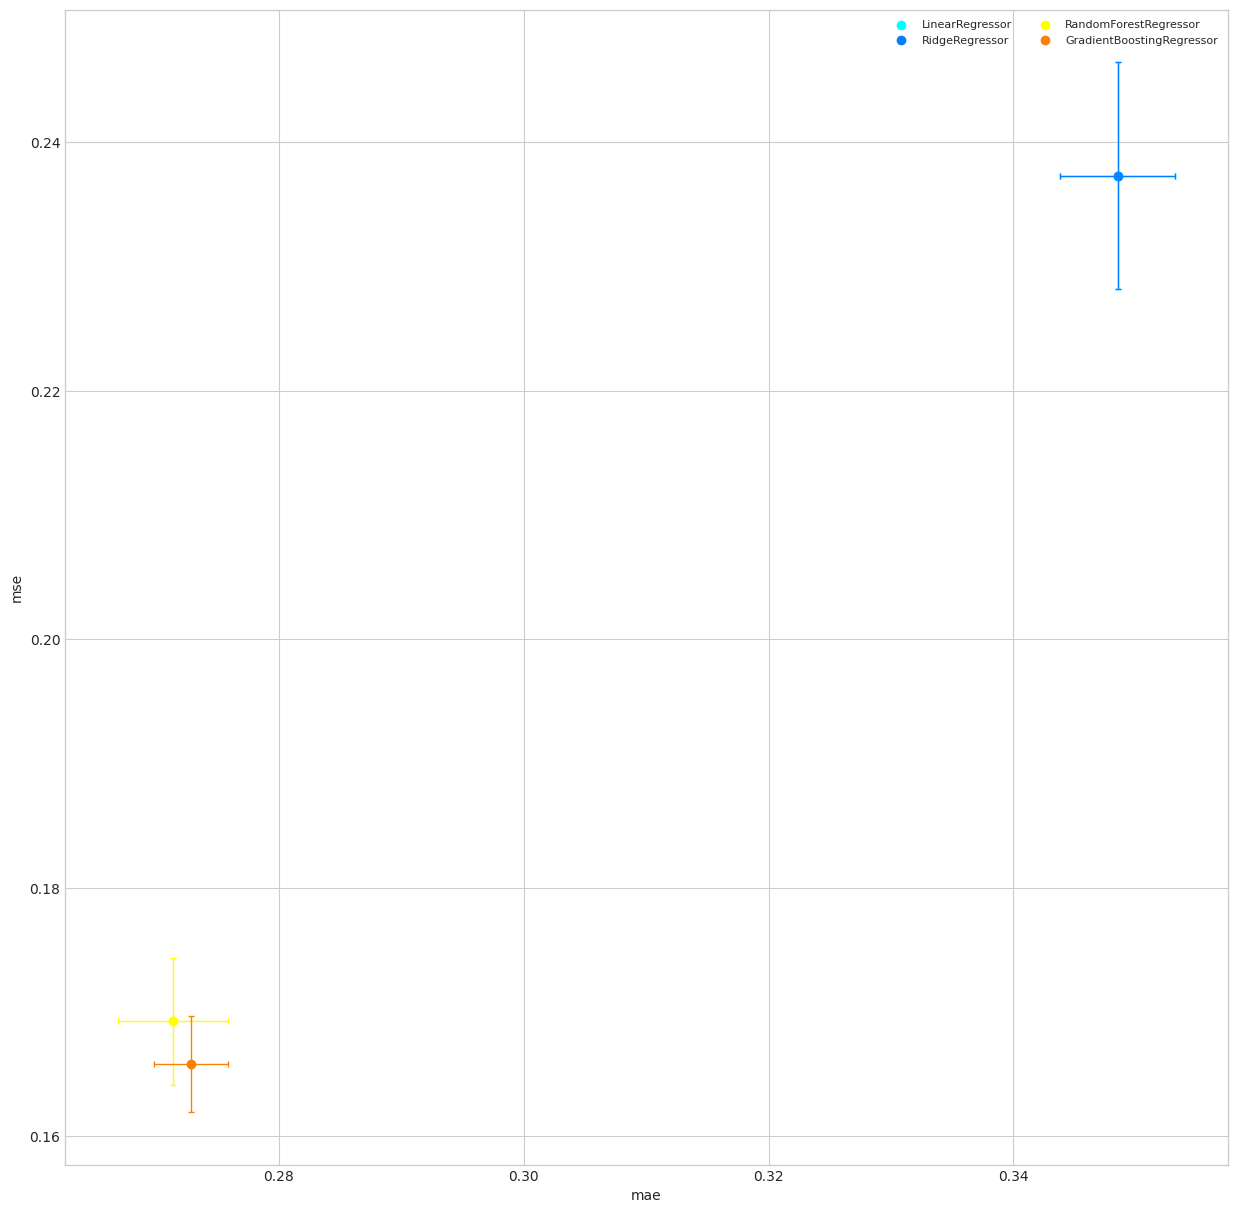

TypeError: 'NoneType' object is not iterable

In [11]:
scatter_result(Metrics_performance, list_component_name, dict_perf, colors)

# Define Encapsulated-visualisation using stored resultat of benchmark as input.
import matplotlib.pyplot as plt


def plot_regression(y, output, context, metadata, size, name, **kwarg):

    y_pred = output
    plt.figure(figsize=(size[0], size[1]))
    plt.title(name)
    plt.plot(y_pred, "black", label="Prediction")
    plt.plot(y,
            "darkgreen",
            marker="X",
            markersize=2,
            linewidth=0,
            label="Observation (inside PI)",
            zorder=20)

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend(loc=1)
    plt.show()

trainset_name = 'syn_[0]'
set_name = 'syn_[1]'
plot_curve(storing, list_component_name, trainset_name, set_name, plot_regression, size=(20, 2.5),plot_param={})

In [19]:
a = get_ABloader('result','syn__[2]')

In [20]:
a

In [16]:
a

In [14]:
for (X,y),context,metadata in a:
    print('a')

TypeError: 'NoneType' object is not iterable

In [7]:
plan_reduced = {'syn_[0]': ['syn_[1]'],'syn_[0 1 2]': ['syn_[3]'], 'syn_[0 1 2 3 4]': ['syn_[5]']}
perf_agg_compute(storing=storing,
                 experiment_plan=plan_reduced,
                 list_component_name=list_component_name,
                 list_metrics=list_metrics,
                 agg_name='reduced')

LinearRegressor mae Train 0.356 ± 0.006 | TEST 0.353 ± 0.01
LinearRegressor mse Train 0.249 ± 0.009 | TEST 0.248 ± 0.017
RidgeRegressor mae Train 0.356 ± 0.006 | TEST 0.353 ± 0.01
RidgeRegressor mse Train 0.249 ± 0.009 | TEST 0.248 ± 0.017
RandomForestRegressor mae Train 0.105 ± 0.004 | TEST 0.275 ± 0.008
RandomForestRegressor mse Train 0.025 ± 0.002 | TEST 0.174 ± 0.007
GradientBoostingRegressor mae Train 0.251 ± 0.004 | TEST 0.275 ± 0.006
GradientBoostingRegressor mse Train 0.133 ± 0.007 | TEST 0.171 ± 0.005


In [9]:
dict_perf = get_dictperf(storing,'all')

In [11]:
from abench.Visualisation import extract_tabular_data, print_flexible_latex_table
dict_perf = get_dictperf(storing,'all')
data = extract_tabular_data(
    nested_dict=dict_perf,
    row_levels=[0, 1],        # Model, Fold
    col_levels=[2, 3],        # Dataset (Test/Val), Metric (Accuracy/F1)
    value_level='mean_test',
    filter_keys={0:["all","reduced"],1: ["LinearRegressor","RidgeRegressor"],2:['mae','rmse']}  # Only extract Accuracy
)

print_flexible_latex_table(data)

\begin{table}[h!]
\centering
\begin{tabular}{|c|c|c|c|c|c|}
\hline
\textbf{Group} & \textbf{Group} & \multicolumn{1}{c}{\textbf{mae}} & \multicolumn{1}{c}{\textbf{mae}} & \multicolumn{1}{c}{\textbf{mae}} & \multicolumn{1}{c}{\textbf{mae}} \\
\hline
 &  & \textbf{mean_test} & \textbf{mean_train} & \textbf{std_test} & \textbf{std_train} \\
\hline
\textbf{all} & LinearRegressor & 0.348511008485263 & 0.3566828368916902 & 0.009363953769342995 & 0.0056085418569268046 \\
\hline
\textbf{all} & RidgeRegressor & 0.34850960498439204 & 0.35668999075579233 & 0.009361898906441103 & 0.005613524861231308 \\
\hline
\end{tabular}
\caption{Metrics Table}
\label{tab:metrics}
\end{table}
